# NOTEBOOK 2 : Predicting Singer Gender from Song Lyrics

#### Made by **Noam Chabot**, **Lélie Chenouga**, **Tabara Guissé**

In this notebook, we predict the singer gender from the song lyrics. To do so, we take as an input the song lyrics and expect the output to be a binary gender label of the credited singer, encoded as male = 0 and female = 1.

The dataset we use to do so is lyrics_gender.csv, expected to contain the columns artist_name, lyrics, and genre, where genre actually stores the gender label.

We compare two models:
1. TF-IDF + linear classifier baseline.
2. Fine-tuned BERT classifier.

## Methodological decisions

To clean our dataset, we ressorted to a number of data manipulations.

 - **We renamed the column "genre" to "gender"** (so the gender refer to the gender label, not to the music genre).

 - **Artists credited as collaborations were excluded by default.** Multi-artist credits such as "Artist A, Artist B", "feat.", "ft.", or "&" can make the gender label ambiguous, so we removed these rows.

 - **We kept the pronouns in the TF-IDF features.**
   Pronouns such as "he", "she", "her", "his", "I" and "you" may be predictive so they are kept even if the model may partly rely on direct self-reference or address patterns rather than deepeer stylistic difference.

- **We didn't use undersampling.**
   The dataset is class-imbalanced, with male artists likely overrepresented. Instead of discarding data, we use class weighting: "class_weight='balanced'" for sklearn models and weighted cross-entropy for BERT.

 - **Train/validation/test split is performed by artist, not by song.**
   This prevents artist leakage: songs by the same artist cannot appear in both train and test.

 - **We use different text inputs for TF-IDF and BERT.**  
   TF-IDF receives strongly cleaned lyrics. BERT receives lightly cleaned lyrics because Transformer models are designed for more natural text.

- **We had to make BERT uses truncation to the first 512 tokens.**  
   We did this beacause it was simple and reproducible, but it must be mentioned as a limitation because lyrics can be longer than 512 tokens.

## 1. Environment setup and configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.1 Imports


In [ ]:
!pip install -q pandas numpy scikit-learn matplotlib seaborn nltk pyarrow joblib tqdm torch transformers statsmodels scipy

In [ ]:

# Core imports

import os
import re
import sys
import json
import time
import math
import random
import shutil
import subprocess
import unicodedata
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Visualization
import seaborn as sns

# Classical ML
import joblib
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.utils.class_weight import compute_class_weight

# NLTK stopwords
import nltk
from nltk.corpus import stopwords

# Progress bars
from tqdm.auto import tqdm

# Deep learning imports are loaded later in the BERT section.

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)

### 1.2 Global configuration

In [ ]:

# Global configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Input data
DATA_PATH = Path("lyrics_gender.csv")


# Project directories
PROJECT_DIR = Path("nlp_lyrics_gender_project")
INTERIM_DIR = PROJECT_DIR / "data" / "interim"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"

for folder in [INTERIM_DIR, PROCESSED_DIR, RESULTS_DIR, FIGURES_DIR, MODELS_DIR, LOGS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Data decisions
DROP_MULTI_ARTIST_CREDITS = True
USE_LANGUAGE_FILTER = os.getenv("USE_LANGUAGE_FILTER", "0") == "1"  # Set env USE_LANGUAGE_FILTER=1 to activate.
LANGUAGE_CONFIDENCE_THRESHOLD = 0.90
MAX_SONGS = int(os.getenv("MAX_SONGS")) if os.getenv("MAX_SONGS") else None  # Example: set MAX_SONGS=20000 for a smaller run.

# Text preprocessing decisions
KEEP_PRONOUNS = True
NORMALIZE_INFORMAL_FORMS = False  # If True, maps "gonna" -> "going to", etc. Kept False to preserve lyrical style.

# TF-IDF decisions
TFIDF_PARAM_GRID = [
    {"max_features": 30000, "ngram_range": (1, 1), "min_df": 5, "max_df": 0.90, "sublinear_tf": True},
    {"max_features": 30000, "ngram_range": (1, 2), "min_df": 5, "max_df": 0.90, "sublinear_tf": True},
    {"max_features": 50000, "ngram_range": (1, 1), "min_df": 5, "max_df": 0.90, "sublinear_tf": True},
    {"max_features": 50000, "ngram_range": (1, 2), "min_df": 5, "max_df": 0.90, "sublinear_tf": True},
]

CLASSIFIER_PARAM_GRID = [
    {"model_name": "logistic_regression", "C": 0.5},
    {"model_name": "logistic_regression", "C": 1.0},
    {"model_name": "logistic_regression", "C": 2.0},
    {"model_name": "linear_svc", "C": 0.5},
    {"model_name": "linear_svc", "C": 1.0},
    {"model_name": "linear_svc", "C": 2.0},
]

# BERT decisions
RUN_BERT = os.getenv("RUN_BERT", "1") == "1"  # Set env RUN_BERT=0 or use run_all.sh --skip-bert to skip BERT.
BERT_MODEL_NAME = "bert-base-uncased"
MAX_LENGTH = 512
BERT_BATCH_SIZE = 16
BERT_EPOCHS = 3
BERT_LR = 2e-5
BERT_WEIGHT_DECAY = 0.01
BERT_EARLY_STOPPING_PATIENCE = 2

# Figure options
SAVE_FIGURES = True
FIGURE_DPI = 300

print("Data path:", DATA_PATH)
print("Project directory:", PROJECT_DIR.resolve())

Data path: lyrics_gender.csv
Project directory: /content/nlp_lyrics_gender_project


### 1.3 Utility functions

In [ ]:

# Utility functions

def save_json(data, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, indent=2, ensure_ascii=False)


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def safe_to_parquet(dataframe: pd.DataFrame, path: Path) -> None:
    """Save as parquet, with a CSV fallback if pyarrow/fastparquet is unavailable."""
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        dataframe.to_parquet(path, index=False)
    except Exception as exc:
        fallback_path = path.with_suffix(".csv")
        print(f"Could not save parquet because: {exc}")
        print(f"Saving CSV fallback instead: {fallback_path}")
        dataframe.to_csv(fallback_path, index=False)


def compute_metrics(y_true, y_pred, labels=(0, 1)) -> dict:
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    precision_per_class, recall_per_class, f1_per_class, support_per_class = precision_recall_fscore_support(
        y_true, y_pred, labels=list(labels), average=None, zero_division=0
    )

    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
        "precision_male": float(precision_per_class[0]),
        "recall_male": float(recall_per_class[0]),
        "f1_male": float(f1_per_class[0]),
        "support_male": int(support_per_class[0]),
        "precision_female": float(precision_per_class[1]),
        "recall_female": float(recall_per_class[1]),
        "f1_female": float(f1_per_class[1]),
        "support_female": int(support_per_class[1]),
    }


def save_figure(path: Path) -> None:
    if SAVE_FIGURES:
        path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(path, dpi=FIGURE_DPI, bbox_inches="tight")
        print(f"Saved figure: {path}")


def add_panel_label(ax, label: str) -> None:
    ax.text(
        -0.10,
        1.08,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top",
        ha="right",
    )


def make_classifier(model_name: str, C: float):
    if model_name == "logistic_regression":
        return LogisticRegression(
            C=C,
            class_weight="balanced",
            max_iter=3000,
            solver="liblinear",
            random_state=SEED,
        )
    if model_name == "linear_svc":
        return LinearSVC(
            C=C,
            class_weight="balanced",
            max_iter=5000,
            random_state=SEED,
        )
    raise ValueError(f"Unknown model name: {model_name}")

## 2. Data loading and quality control

### 2.1 Loading and inspection of the dataset

In [ ]:
drive.mount('/content/drive')
file_name = "/content/drive/MyDrive/lyrics_gender.csv"


df = pd.read_csv(file_name)
df.columns = df.columns.str.strip().str.lower()



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df

,artist_name,lyrics,genre
0,Nick Lowe,I should be filling rooms with the sweet smell of success\n I'm a mess look at what I've been reduced to\n I don't b...,male
1,Matt Maltese,You can act all shy\n But you know that I want you\n ♪\n In the dead of night\n I want to live with you\n So terrifi...,male
2,Talsur,We are lost. Helpless and left before raining\n Hearts as ghosts. Shattered in vain\n Neverness is better of course ...,male
3,Teena Marie,"Oh hey, baby (oh yeah?)\n Let me take you to Xanadu (where's that?)\n Behind the groove (well, alright, hoo)\n ♪\n (...",female
4,Sander W.,"Hey, must have been a few years\n Your face turned darker\n My eyes went brighter\n Hey, must have been a few years\...",male
...,...,...,...
22495,Loïc Nottet,"Farewell, farewell\n Farewell, farewell\n Farewell, farewell\n Farewell, farewell\n Farewell (Farewell)\n Farewell (...",male
22496,Ryan Adams,"The sun is shining hard at my feet\n And the city is an animal ready to eat\n It's raining like a nose bleed, cigare...",male
22497,Muddy Waters,"I am, ohh i am the blues.\n I know the world knows ive been mistreated\n And the whole world know ive been misused\n...",male
22498,Kat McDowell,Wake up it's the morning\n Don't dive back under the covers\n You say life is boring but I\n I can not believe you\n...,female


In [ ]:
# Standardize column names and core labels

required_columns = {"artist_name", "lyrics", "genre"}
missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

df = df.rename(columns={
    "lyrics": "lyrics_raw",
    "genre": "gender",
})

df = df[["artist_name", "lyrics_raw", "gender"]].copy()

# Basic type cleaning
df["artist_name"] = df["artist_name"].astype(str).str.strip()
df["lyrics_raw"] = df["lyrics_raw"].astype(str)
df["gender"] = df["gender"].astype(str).str.lower().str.strip()


df["gender_label"] = df["gender"].map({
    "male": 0,
    "female": 1,
}).astype(int)

print("Shape after standardization:", df.shape)
print(df["gender"].value_counts())

Shape after standardization: (22500, 4)
gender
male      16324
female     6176
Name: count, dtype: int64


In [ ]:
# Initial missing values and duplicates check

initial_diagnostics = {
    "n_rows": int(len(df)),
    "missing_artist_name": int(df["artist_name"].isna().sum()),
    "missing_lyrics_raw": int(df["lyrics_raw"].isna().sum()),
    "missing_gender": int(df["gender"].isna().sum()),
    "duplicate_artist_lyrics": int(df.duplicated(subset=["artist_name", "lyrics_raw"]).sum()),
    "duplicate_lyrics_only": int(df.duplicated(subset=["lyrics_raw"]).sum()),
}

save_json(initial_diagnostics, LOGS_DIR / "initial_diagnostics.json")
initial_diagnostics

{'n_rows': 22500,
 'missing_artist_name': 0,
 'missing_lyrics_raw': 0,
 'missing_gender': 0,
 'duplicate_artist_lyrics': 0,
 'duplicate_lyrics_only': 0}

### Artist-name normalization and ambiguous credit filtering

In [ ]:

# Artist-name normalization

def normalize_artist_name(name: str) -> str:
    if not isinstance(name, str):
        return ""

    name = unicodedata.normalize("NFKD", name)
    name = "".join(char for char in name if not unicodedata.combining(char))

    name = name.lower().strip()
    name = re.sub(r"[’‘`´]", "'", name)
    name = re.sub(r"[^a-z0-9&,+/\-'\s]", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    return name


df["artist_name_normalized"] = df["artist_name"].apply(normalize_artist_name)

print("Unique artists before filtering:", df["artist_name_normalized"].nunique())
display(df[["artist_name", "artist_name_normalized"]].head(10))

Unique artists before filtering: 10396


,artist_name,artist_name_normalized
0,Nick Lowe,nick lowe
1,Matt Maltese,matt maltese
2,Talsur,talsur
3,Teena Marie,teena marie
4,Sander W.,sander w
5,Andrew Rayel,andrew rayel
6,Murphy Elmore,murphy elmore
7,Tom Morello,tom morello
8,Sandra McCracken,sandra mccracken
9,Barry Manilow,barry manilow


In [ ]:

# Multi-artist credit detection

def looks_like_multi_artist_credit(name: str) -> bool:
    if not isinstance(name, str):
        return False

    name = name.lower()

    patterns = [
        r",",
        r"\s&\s",
        r"\bfeat\.?\b",
        r"\bft\.?\b",
        r"\bfeaturing\b",
    ]

    return any(re.search(pattern, name) for pattern in patterns)


df["is_multi_artist_credit"] = df["artist_name"].apply(looks_like_multi_artist_credit)

multi_artist_summary = {
    "n_multi_artist_rows": int(df["is_multi_artist_credit"].sum()),
    "share_multi_artist_rows": float(df["is_multi_artist_credit"].mean()),
}

print(multi_artist_summary)
display(df.loc[df["is_multi_artist_credit"], ["artist_name", "gender"]].head(10))

save_json(multi_artist_summary, LOGS_DIR / "multi_artist_summary.json")

{'n_multi_artist_rows': 2032, 'share_multi_artist_rows': 0.0903111111111111}


,artist_name,gender
19,"Drake, Pimp C, dvsn",male
20,"Jhené Aiko, Namiko, Miyagi",female
26,"Josh A, Quadeca",male
28,"Lightworker, Laura McElroy",female
35,"Jessica Keenan Wynn, Alice Lee, Elle McLemore",male
39,"Paul Woolford, Karen Harding",male
44,"Katy B, Ms. Dynamite",female
64,"The Weeknd, Sebastian Ingrosso, Salvatore Ganacci",male
75,"GRiZ, ProbCause",male
85,"Louis Armstrong, Michael McDonald",male


In [ ]:

# Apply multi-artist filtering decision

before_filtering = len(df)
df = df[~df["is_multi_artist_credit"]].copy()
after_filtering = len(df)
print(f"Removed {before_filtering - after_filtering} rows with potentially ambiguous multi-artist credits.")


Removed 2032 rows with potentially ambiguous multi-artist credits.


### Lyrics preprocessing

Two versions of the lyrics are created:

- "lyrics_clean_tfidf": strongly cleaned text for TF-IDF.
- "lyrics_clean_bert": lightly cleaned text for BERT.

This distinction is important. TF-IDF benefits from explicit normalization and noise removal. BERT should receive text that remains closer to natural language.

In [ ]:

# Prepare NLTK stopwords

try:
    english_stopwords = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    english_stopwords = set(stopwords.words("english"))

pronouns_to_keep = {
    "he", "him", "his", "himself",
    "she", "her", "hers", "herself",
    "i", "me", "my", "mine", "myself",
    "you", "your", "yours", "yourself",
    "we", "us", "our", "ours",
    "they", "them", "their", "theirs",
}

if KEEP_PRONOUNS:
    project_stopwords = english_stopwords - pronouns_to_keep
else:
    project_stopwords = english_stopwords

print("Number of stopwords used:", len(project_stopwords))
print("Pronouns kept:", KEEP_PRONOUNS)

Number of stopwords used: 175
Pronouns kept: True


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:

# Text cleaning functions

contractions = {
    "it's": "it is",
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "you're": "you are",
    "i'm": "i am",
    "he's": "he is",
    "she's": "she is",
    "they're": "they are",
    "we're": "we are",
    "can't": "cannot",
    "won't": "will not",
    "ain't": "is not",
    "i've": "i have",
    "you've": "you have",
    "we've": "we have",
    "they've": "they have",
    "i'll": "i will",
    "you'll": "you will",
    "he'll": "he will",
    "she'll": "she will",
    "they'll": "they will",
    "i'd": "i would",
    "you'd": "you would",
    "he'd": "he would",
    "she'd": "she would",
    "we'd": "we would",
    "they'd": "they would",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "couldn't": "could not",
    "mustn't": "must not",
}

informal_forms = {
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "lemme": "let me",
    "gimme": "give me",
}

contraction_pattern = re.compile(
    r"\b(" + "|".join(re.escape(key) for key in contractions.keys()) + r")\b"
)

informal_pattern = re.compile(
    r"\b(" + "|".join(re.escape(key) for key in informal_forms.keys()) + r")\b"
)


def expand_contractions(text: str) -> str:
    text = contraction_pattern.sub(lambda match: contractions[match.group(0)], text)

    if NORMALIZE_INFORMAL_FORMS:
        text = informal_pattern.sub(lambda match: informal_forms[match.group(0)], text)

    return text


def clean_lyrics_for_tfidf(text: str, remove_stopwords: bool = True) -> str:
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = re.sub(r"[’‘`´]", "'", text)

    # Remove lyric structure tags such as [Verse 1], [Chorus], [Bridge], [Hook]
    text = re.sub(r"\[[^\]]*\]", " ", text)

    # Remove structural repetition markers such as (x4), (repeat), (chorus x2)
    text = re.sub(
        r"\([^)]*(?:x\d+|repeat|chorus|verse|hook)[^)]*\)",
        " ",
        text,
        flags=re.IGNORECASE,
    )
    text = re.sub(r"\bx\d+\b", " ", text)

    # Normalize common English contractions before punctuation removal
    text = expand_contractions(text)

    # Remove punctuation while keeping apostrophes for remaining internal forms
    text = re.sub(r"[^\w\s']|_", " ", text)

    # Remove isolated numbers
    text = re.sub(r"\b\d+\b", " ", text)

    words = text.split()

    if remove_stopwords:
        words = [word for word in words if word not in project_stopwords]

    return " ".join(words)


def clean_lyrics_for_bert(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = re.sub(r"[’‘`´]", "'", text)

    # Remove lyric structure tags, but keep the text close to natural language
    text = re.sub(r"\[[^\]]*\]", " ", text)

    # Remove repetition markers
    text = re.sub(
        r"\([^)]*(?:x\d+|repeat|chorus|verse|hook)[^)]*\)",
        " ",
        text,
        flags=re.IGNORECASE,
    )
    text = re.sub(r"\bx\d+\b", " ", text, flags=re.IGNORECASE)

    # Keep punctuation and stopwords for BERT
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:

# Apply lyrics preprocessing

print("Cleaning lyrics for TF-IDF...")
df["lyrics_clean_tfidf"] = df["lyrics_raw"].apply(clean_lyrics_for_tfidf)

print("Cleaning lyrics for BERT...")
df["lyrics_clean_bert"] = df["lyrics_raw"].apply(clean_lyrics_for_bert)

# Remove rows that become empty after cleaning
before_empty_filtering = len(df)
df = df[df["lyrics_clean_tfidf"].str.strip().ne("")].copy()
after_empty_filtering = len(df)

print(f"Removed {before_empty_filtering - after_empty_filtering} rows with empty cleaned lyrics.")
print("Shape after text preprocessing:", df.shape)

display(df[["lyrics_raw", "lyrics_clean_tfidf", "lyrics_clean_bert"]].head(3))

Cleaning lyrics for TF-IDF...
Cleaning lyrics for BERT...
Removed 0 rows with empty cleaned lyrics.
Shape after text preprocessing: (20468, 8)


,lyrics_raw,lyrics_clean_tfidf,lyrics_clean_bert
0,I should be filling rooms with the sweet smell of success\n I'm a mess look at what I've been reduced to\n I don't b...,i filling rooms sweet smell success i mess look i reduced i blame you sayin' you said yes darlin' darlin' darlin' lo...,I should be filling rooms with the sweet smell of success I'm a mess look at what I've been reduced to I don't blame...
1,You can act all shy\n But you know that I want you\n ♪\n In the dead of night\n I want to live with you\n So terrifi...,you act shy you know i want you dead night i want live you terrified road takes you me modify every one adores you l...,You can act all shy But you know that I want you ♪ In the dead of night I want to live with you So terrified of the ...
2,We are lost. Helpless and left before raining\n Hearts as ghosts. Shattered in vain\n Neverness is better of course ...,we lost helpless left raining hearts ghosts shattered vain neverness better course forever breathless ways away pain...,We are lost. Helpless and left before raining Hearts as ghosts. Shattered in vain Neverness is better of course than...


## III. Data analysis

In [ ]:

# Descriptive corpus statistics

df["raw_word_count"] = df["lyrics_raw"].str.split().str.len()
df["tfidf_word_count"] = df["lyrics_clean_tfidf"].str.split().str.len()
df["bert_word_count"] = df["lyrics_clean_bert"].str.split().str.len()

artist_song_counts = df.groupby("artist_name_normalized").size()

corpus_stats = {
    "n_songs": int(len(df)),
    "n_artists": int(df["artist_name_normalized"].nunique()),
    "class_distribution": df["gender"].value_counts().to_dict(),
    "class_distribution_percent": (df["gender"].value_counts(normalize=True) * 100).round(2).to_dict(),
    "raw_word_count": df["raw_word_count"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_dict(),
    "tfidf_word_count": df["tfidf_word_count"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_dict(),
    "bert_word_count": df["bert_word_count"].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_dict(),
    "songs_per_artist": artist_song_counts.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_dict(),
}

save_json(corpus_stats, RESULTS_DIR / "corpus_stats.json")
corpus_stats

{'n_songs': 20468,
 'n_artists': 8569,
 'class_distribution': {'male': 14811, 'female': 5657},
 'class_distribution_percent': {'male': 72.36, 'female': 27.64},
 'raw_word_count': {'count': 20468.0,
  'mean': 305.1139339456713,
  'std': 246.85900839388736,
  'min': 2.0,
  '50%': 247.0,
  '90%': 544.0,
  '95%': 696.0,
  '99%': 1329.3199999999924,
  'max': 4350.0},
 'tfidf_word_count': {'count': 20468.0,
  'mean': 203.93497166308384,
  'std': 171.42444252542376,
  'min': 1.0,
  '50%': 161.0,
  '90%': 374.0,
  '95%': 480.6499999999978,
  '99%': 910.6599999999962,
  'max': 2835.0},
 'bert_word_count': {'count': 20468.0,
  'mean': 304.95729919874924,
  'std': 246.81380277610538,
  'min': 2.0,
  '50%': 247.0,
  '90%': 543.0,
  '95%': 696.0,
  '99%': 1329.3199999999924,
  'max': 4350.0},
 'songs_per_artist': {'count': 8569.0,
  'mean': 2.3886101061967557,
  'std': 3.3027294039448325,
  'min': 1.0,
  '50%': 1.0,
  '90%': 5.0,
  '95%': 7.0,
  '99%': 15.0,
  'max': 83.0}}

Saved figure: nlp_lyrics_gender_project/results/figures/figure_1_corpus_overview.png


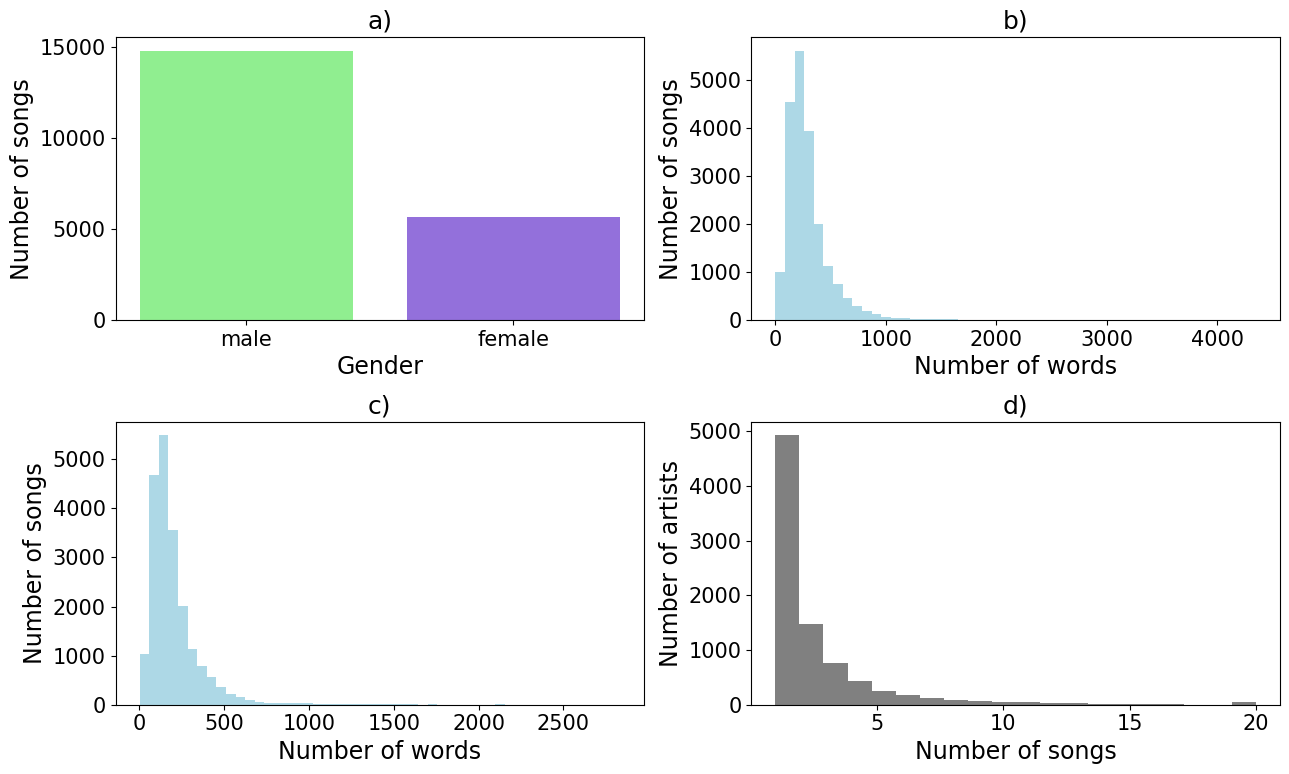

In [ ]:
# Figure 1: Corpus overview

def plot_corpus_overview(dataframe: pd.DataFrame, output_path: Path) -> None:
    title_size = 18
    label_size = 17
    tick_size = 15

    fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
    fig.suptitle("", fontsize=16)

    class_counts = dataframe["gender"].value_counts().reindex(["male", "female"])
    axes[0, 0].bar(class_counts.index, class_counts.values, color=["lightgreen", "mediumpurple"])
    axes[0, 0].set_title("a)", fontsize=title_size, fontweight="normal")
    axes[0, 0].set_xlabel("Gender", fontsize=label_size)
    axes[0, 0].set_ylabel("Number of songs", fontsize=label_size)
    axes[0, 0].tick_params(labelsize=tick_size)

    axes[0, 1].hist(dataframe["raw_word_count"], bins=50, color="lightblue")
    axes[0, 1].set_title("b)", fontsize=title_size, fontweight="normal")
    axes[0, 1].set_xlabel("Number of words", fontsize=label_size)
    axes[0, 1].set_ylabel("Number of songs", fontsize=label_size)
    axes[0, 1].tick_params(labelsize=tick_size)

    axes[1, 0].hist(dataframe["tfidf_word_count"], bins=50, color="lightblue")
    axes[1, 0].set_title("c)", fontsize=title_size, fontweight="normal")
    axes[1, 0].set_xlabel("Number of words", fontsize=label_size)
    axes[1, 0].set_ylabel("Number of songs", fontsize=label_size)
    axes[1, 0].tick_params(labelsize=tick_size)

    artist_counts = dataframe.groupby("artist_name_normalized").size()
    axes[1, 1].hist(artist_counts.clip(upper=20), bins=20, color="gray")
    axes[1, 1].set_title("d)", fontsize=title_size, fontweight="normal")
    axes[1, 1].set_xlabel("Number of songs", fontsize=label_size)
    axes[1, 1].set_ylabel("Number of artists", fontsize=label_size)
    axes[1, 1].tick_params(labelsize=tick_size)

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    save_figure(output_path)
    plt.show()


plot_corpus_overview(df, FIGURES_DIR / "figure_1_corpus_overview.png")

### Artist-level train / validation / test split

The split is made at the artist level:

- 70% train artists;
- 15% validation artists;
- 15% test artists.

All songs by the same artist are assigned to the same split. This prevents data leakage from artist-specific vocabulary, themes, or recurrent stylistic habits.

In [ ]:

# Remove any normalized artist with contradictory labels

artist_label_counts = df.groupby("artist_name_normalized")["gender_label"].nunique()
ambiguous_artists = artist_label_counts[artist_label_counts > 1].index.tolist()

print("Ambiguous normalized artists:", len(ambiguous_artists))

if ambiguous_artists:
    save_json({"ambiguous_artists": ambiguous_artists}, LOGS_DIR / "ambiguous_artists.json")
    df = df[~df["artist_name_normalized"].isin(ambiguous_artists)].copy()

artist_df = (
    df[["artist_name_normalized", "gender_label", "gender"]]
    .drop_duplicates(subset=["artist_name_normalized"])
    .reset_index(drop=True)
)

print("Number of unique artists used for splitting:", len(artist_df))
display(artist_df["gender"].value_counts())

Ambiguous normalized artists: 2
Number of unique artists used for splitting: 8567


,count
gender,
male,6220
female,2347


In [ ]:

# Stratified split at artist level

train_artists, temp_artists = train_test_split(
    artist_df,
    test_size=0.30,
    random_state=SEED,
    stratify=artist_df["gender_label"],
)

val_artists, test_artists = train_test_split(
    temp_artists,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_artists["gender_label"],
)

split_map = {}
for split_name, split_artists in [
    ("train", train_artists),
    ("val", val_artists),
    ("test", test_artists),
]:
    split_map.update({
        artist: split_name
        for artist in split_artists["artist_name_normalized"]
    })

df["split"] = df["artist_name_normalized"].map(split_map)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)
test_df = df[df["split"] == "test"].reset_index(drop=True)

train_df["split_row_id"] = np.arange(len(train_df))
val_df["split_row_id"] = np.arange(len(val_df))
test_df["split_row_id"] = np.arange(len(test_df))

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

display(pd.crosstab(df["split"], df["gender"], normalize="index"))

Train shape: (14419, 13)
Validation shape: (2992, 13)
Test shape: (3049, 13)


gender,female,male
split,,
test,0.313545,0.686455
train,0.272349,0.727651
val,0.257019,0.742981


In [ ]:

# Leakage checks

artist_sets = {
    "train": set(train_df["artist_name_normalized"]),
    "val": set(val_df["artist_name_normalized"]),
    "test": set(test_df["artist_name_normalized"]),
}

assert artist_sets["train"].isdisjoint(artist_sets["val"]), "Leakage between train and validation artists."
assert artist_sets["train"].isdisjoint(artist_sets["test"]), "Leakage between train and test artists."
assert artist_sets["val"].isdisjoint(artist_sets["test"]), "Leakage between validation and test artists."

split_diagnostics = {
    "n_train_rows": int(len(train_df)),
    "n_val_rows": int(len(val_df)),
    "n_test_rows": int(len(test_df)),
    "n_train_artists": int(train_df["artist_name_normalized"].nunique()),
    "n_val_artists": int(val_df["artist_name_normalized"].nunique()),
    "n_test_artists": int(test_df["artist_name_normalized"].nunique()),
    "train_class_distribution": train_df["gender"].value_counts().to_dict(),
    "val_class_distribution": val_df["gender"].value_counts().to_dict(),
    "test_class_distribution": test_df["gender"].value_counts().to_dict(),
}

save_json(split_diagnostics, LOGS_DIR / "split_diagnostics.json")
print("No artist leakage across splits.")
split_diagnostics

No artist leakage across splits.


{'n_train_rows': 14419,
 'n_val_rows': 2992,
 'n_test_rows': 3049,
 'n_train_artists': 5996,
 'n_val_artists': 1285,
 'n_test_artists': 1286,
 'train_class_distribution': {'male': 10492, 'female': 3927},
 'val_class_distribution': {'male': 2223, 'female': 769},
 'test_class_distribution': {'male': 2093, 'female': 956}}

Saved figure: nlp_lyrics_gender_project/results/figures/figure_2_split_diagnostics.png


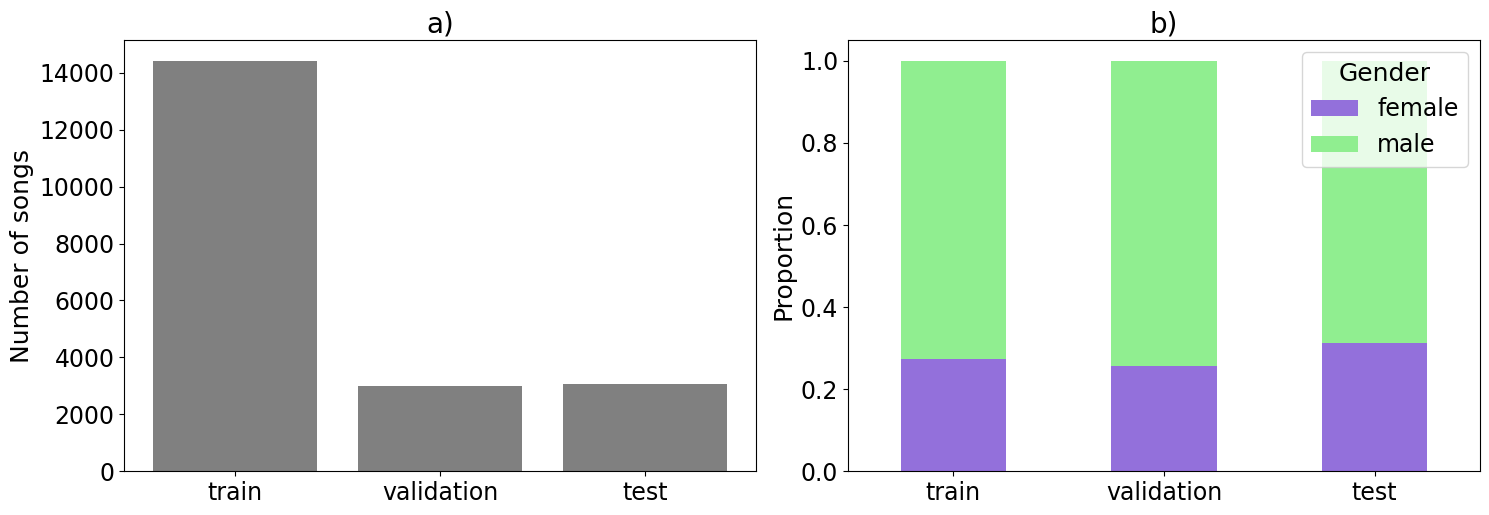

In [ ]:
# Figure 2: Split diagnostics

def plot_split_diagnostics(train_df, val_df, test_df, output_path: Path) -> None:
    title_size = 20
    label_size = 18
    tick_size = 17

    combined = pd.concat([
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test"),
    ], ignore_index=True)

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle("", fontsize=16)

    split_counts = combined["split"].value_counts().reindex(["train", "validation", "test"])
    axes[0].bar(split_counts.index, split_counts.values, color="gray")
    axes[0].set_title("a)", fontsize=title_size, fontweight="normal")
    axes[0].set_ylabel("Number of songs", fontsize=label_size)
    axes[0].tick_params(labelsize=tick_size, rotation=0)

    split_gender = pd.crosstab(combined["split"], combined["gender"], normalize="index").reindex(["train", "validation", "test"])
    split_gender.plot(kind="bar", stacked=True, ax=axes[1], color=["mediumpurple", "lightgreen"], rot=0)
    axes[1].set_title("b)", fontsize=title_size, fontweight="normal")
    axes[1].set_ylabel("Proportion", fontsize=label_size)
    axes[1].set_xlabel("", fontsize=label_size)
    axes[1].legend(title="Gender", fontsize=tick_size, title_fontsize=label_size)
    axes[1].tick_params(labelsize=tick_size)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    save_figure(output_path)
    plt.show()


plot_split_diagnostics(train_df, val_df, test_df, FIGURES_DIR / "figure_2_split_diagnostics.png")

In [ ]:

# Save preprocessed and split datasets

columns_to_save = [
    "artist_name",
    "artist_name_normalized",
    "lyrics_raw",
    "lyrics_clean_tfidf",
    "lyrics_clean_bert",
    "gender",
    "gender_label",
    "split",
    "raw_word_count",
    "tfidf_word_count",
    "bert_word_count",
]

safe_to_parquet(df[columns_to_save], INTERIM_DIR / "preprocessed.parquet")
safe_to_parquet(train_df[columns_to_save + ["split_row_id"]], PROCESSED_DIR / "train.parquet")
safe_to_parquet(val_df[columns_to_save + ["split_row_id"]], PROCESSED_DIR / "val.parquet")
safe_to_parquet(test_df[columns_to_save + ["split_row_id"]], PROCESSED_DIR / "test.parquet")

train_artists.to_csv(PROCESSED_DIR / "train_artists.csv", index=False)
val_artists.to_csv(PROCESSED_DIR / "val_artists.csv", index=False)
test_artists.to_csv(PROCESSED_DIR / "test_artists.csv", index=False)

print("Saved preprocessed datasets and artist split logs.")

Saved preprocessed datasets and artist split logs.


## IV. Model 1: TF-IDF



We test whether surface lexical cues are sufficient to predict the singer gender label.

The TF-IDF hyperparameters are tuned on the validation set:

- `max_features`: number of lexical features kept;
- `ngram_range`: unigrams only or unigrams + bigrams;
- `min_df`: minimum number of documents a feature must appear in;
- `max_df`: removes features that are too common;
- `sublinear_tf`: reduces the impact of repeated words, which matters for lyrics.

Two linear classifiers are compared:

- Logistic Regression;
- Linear SVM.

Both use `class_weight='balanced'` because we do not undersample the majority class.

In [ ]:

# TF-IDF model selection on validation set

start_time = time.time()

tfidf_validation_results = []
best_tfidf_bundle = None
best_score = -1.0

for vectorizer_params in TFIDF_PARAM_GRID:
    print("Vectorizer params:", vectorizer_params)

    vectorizer = TfidfVectorizer(**vectorizer_params)
    X_train = vectorizer.fit_transform(train_df["lyrics_clean_tfidf"])
    X_val = vectorizer.transform(val_df["lyrics_clean_tfidf"])

    y_train = train_df["gender_label"].values
    y_val = val_df["gender_label"].values

    for classifier_params in CLASSIFIER_PARAM_GRID:
        classifier = make_classifier(
            model_name=classifier_params["model_name"],
            C=classifier_params["C"],
        )

        classifier.fit(X_train, y_train)
        val_predictions = classifier.predict(X_val)
        metrics = compute_metrics(y_val, val_predictions)

        result = {
            "vectorizer_params": vectorizer_params,
            "classifier_params": classifier_params,
            **metrics,
        }
        tfidf_validation_results.append(result)

        print(
            classifier_params,
            "accuracy=", round(metrics["accuracy"], 4),
            "macro_f1=", round(metrics["f1_macro"], 4),
        )

        # Macro-F1 is used for model selection because the dataset is imbalanced.
        if metrics["f1_macro"] > best_score:
            best_score = metrics["f1_macro"]
            best_tfidf_bundle = {
                "vectorizer_params": vectorizer_params,
                "classifier_params": classifier_params,
                "validation_metrics": metrics,
            }

tfidf_validation_time = time.time() - start_time

validation_results_df = pd.DataFrame(tfidf_validation_results).sort_values("f1_macro", ascending=False)
validation_results_df.to_csv(RESULTS_DIR / "tfidf_validation_results.csv", index=False)
save_json(best_tfidf_bundle, RESULTS_DIR / "tfidf_best_config.json")
save_json(
    {
        "tfidf_validation_search_time_minutes": round(tfidf_validation_time / 60, 2),
        "n_configurations_tested": len(tfidf_validation_results),
    },
    LOGS_DIR / "tfidf_runtime_log.json",
)

print("Best TF-IDF configuration:")
print(best_tfidf_bundle)
print("TF-IDF validation search time in minutes:", round(tfidf_validation_time / 60, 2))

display(validation_results_df.head(10))

Vectorizer params: {'max_features': 30000, 'ngram_range': (1, 1), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}
{'model_name': 'logistic_regression', 'C': 0.5} accuracy= 0.6076 macro_f1= 0.5655
{'model_name': 'logistic_regression', 'C': 1.0} accuracy= 0.6186 macro_f1= 0.5695
{'model_name': 'logistic_regression', 'C': 2.0} accuracy= 0.627 macro_f1= 0.5699
{'model_name': 'linear_svc', 'C': 0.5} accuracy= 0.6193 macro_f1= 0.5582
{'model_name': 'linear_svc', 'C': 1.0} accuracy= 0.6183 macro_f1= 0.5532
{'model_name': 'linear_svc', 'C': 2.0} accuracy= 0.6146 macro_f1= 0.5435
Vectorizer params: {'max_features': 30000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}
{'model_name': 'logistic_regression', 'C': 0.5} accuracy= 0.6143 macro_f1= 0.5671
{'model_name': 'logistic_regression', 'C': 1.0} accuracy= 0.64 macro_f1= 0.5832
{'model_name': 'logistic_regression', 'C': 2.0} accuracy= 0.6591 macro_f1= 0.5906
{'model_name': 'linear_svc', 'C': 0.5} accuracy= 0.6608 macr

,vectorizer_params,classifier_params,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,precision_male,recall_male,f1_male,support_male,precision_female,recall_female,f1_female,support_female
8,"{'max_features': 30000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'logistic_regression', 'C': 2.0}",0.659091,0.588090,0.602597,0.590571,0.691948,0.659091,0.671966,0.801806,0.718848,0.758065,2223,0.374374,0.486346,0.423077,769
20,"{'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'logistic_regression', 'C': 2.0}",0.661096,0.586197,0.598843,0.588879,0.689521,0.661096,0.672614,0.798814,0.726946,0.761187,2223,0.373581,0.470741,0.416571,769
7,"{'max_features': 30000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'logistic_regression', 'C': 1.0}",0.640040,0.584009,0.602960,0.583189,0.691773,0.640040,0.657996,0.805763,0.679262,0.737125,2223,0.362254,0.526658,0.429253,769
19,"{'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'logistic_regression', 'C': 1.0}",0.641043,0.581215,0.598532,0.581077,0.688610,0.641043,0.658100,0.802209,0.686010,0.739573,2223,0.360220,0.511053,0.422581,769
9,"{'max_features': 30000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'linear_svc', 'C': 0.5}",0.660762,0.576316,0.584159,0.578622,0.679670,0.660762,0.669032,0.788995,0.741790,0.764665,2223,0.363636,0.426528,0.392579,769
21,"{'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'linear_svc', 'C': 0.5}",0.664439,0.575649,0.581530,0.577699,0.678272,0.664439,0.670707,0.786824,0.752137,0.769089,2223,0.364475,0.410923,0.386308,769
22,"{'max_features': 50000, 'ngram_range': (1, 2), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'linear_svc', 'C': 1.0}",0.673128,0.572672,0.572919,0.572794,0.673684,0.673128,0.673405,0.780532,0.779127,0.779829,2223,0.364812,0.366710,0.365759,769
2,"{'max_features': 30000, 'ngram_range': (1, 1), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'logistic_regression', 'C': 2.0}",0.627005,0.572304,0.589085,0.569927,0.681858,0.627005,0.646066,0.797741,0.667117,0.726605,2223,0.346867,0.511053,0.413249,769
14,"{'max_features': 50000, 'ngram_range': (1, 1), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'logistic_regression', 'C': 2.0}",0.627005,0.572304,0.589085,0.569927,0.681858,0.627005,0.646066,0.797741,0.667117,0.726605,2223,0.346867,0.511053,0.413249,769
1,"{'max_features': 30000, 'ngram_range': (1, 1), 'min_df': 5, 'max_df': 0.9, 'sublinear_tf': True}","{'model_name': 'logistic_regression', 'C': 1.0}",0.618650,0.575234,0.594944,0.569496,0.686373,0.618650,0.640188,0.803933,0.643725,0.714964,2223,0.346535,0.546164,0.424028,769


In [ ]:

# Train final TF-IDF model on train + validation using the best configuration

train_val_df = pd.concat([train_df, val_df], ignore_index=True)

best_vectorizer_params = best_tfidf_bundle["vectorizer_params"]
best_classifier_params = best_tfidf_bundle["classifier_params"]

final_vectorizer = TfidfVectorizer(**best_vectorizer_params)
X_train_val = final_vectorizer.fit_transform(train_val_df["lyrics_clean_tfidf"])
X_test = final_vectorizer.transform(test_df["lyrics_clean_tfidf"])

y_train_val = train_val_df["gender_label"].values
y_test = test_df["gender_label"].values

final_tfidf_classifier = make_classifier(
    model_name=best_classifier_params["model_name"],
    C=best_classifier_params["C"],
)

final_tfidf_classifier.fit(X_train_val, y_train_val)
tfidf_test_predictions = final_tfidf_classifier.predict(X_test)

tfidf_test_metrics = compute_metrics(y_test, tfidf_test_predictions)
tfidf_confusion = confusion_matrix(y_test, tfidf_test_predictions, labels=[0, 1])
tfidf_report = classification_report(
    y_test,
    tfidf_test_predictions,
    target_names=["male", "female"],
    zero_division=0,
    output_dict=True,
)

tfidf_results = {
    "model": "tfidf_linear_classifier",
    "best_vectorizer_params": best_vectorizer_params,
    "best_classifier_params": best_classifier_params,
    "validation_metrics_for_selected_config": best_tfidf_bundle["validation_metrics"],
    "test_metrics": tfidf_test_metrics,
    "confusion_matrix": tfidf_confusion.tolist(),
    "classification_report": tfidf_report,
}

save_json(tfidf_results, RESULTS_DIR / "tfidf_results.json")

joblib.dump(
    {
        "vectorizer": final_vectorizer,
        "classifier": final_tfidf_classifier,
        "label_mapping": {"male": 0, "female": 1},
        "best_vectorizer_params": best_vectorizer_params,
        "best_classifier_params": best_classifier_params,
    },
    MODELS_DIR / "tfidf_model.joblib",
)

# Save predictions for later comparison and error analysis
tfidf_predictions_df = test_df[[
    "split_row_id",
    "artist_name",
    "artist_name_normalized",
    "lyrics_raw",
    "lyrics_clean_tfidf",
    "gender",
    "gender_label",
    "raw_word_count",
    "tfidf_word_count",
]].copy()

tfidf_predictions_df["tfidf_pred_label"] = tfidf_test_predictions
tfidf_predictions_df["tfidf_pred_gender"] = tfidf_predictions_df["tfidf_pred_label"].map({0: "male", 1: "female"})
tfidf_predictions_df["tfidf_correct"] = tfidf_predictions_df["tfidf_pred_label"] == tfidf_predictions_df["gender_label"]

tfidf_predictions_df.to_csv(RESULTS_DIR / "tfidf_test_predictions.csv", index=False)

print("TF-IDF test metrics:")
print(json.dumps(tfidf_test_metrics, indent=2))
print("Confusion matrix [[male, female], [male, female]]:")
print(tfidf_confusion)

TF-IDF test metrics:
{
  "accuracy": 0.6405378812725484,
  "precision_macro": 0.5951231905437618,
  "recall_macro": 0.601512663250884,
  "f1_macro": 0.5969184569318314,
  "precision_weighted": 0.6545437927976517,
  "recall_weighted": 0.6405378812725484,
  "f1_weighted": 0.6463654015733022,
  "precision_male": 0.7544665645737622,
  "recall_male": 0.7061634018155757,
  "f1_male": 0.7295162882527148,
  "support_male": 2093,
  "precision_female": 0.43577981651376146,
  "recall_female": 0.49686192468619245,
  "f1_female": 0.46432062561094817,
  "support_female": 956
}
Confusion matrix [[male, female], [male, female]]:
[[1478  615]
 [ 481  475]]


### TF-IDF interpretability

For binary linear models, the sign of the coefficient can be interpreted as follows:

- strongly negative coefficients are associated with the `male` class (`0`);
- strongly positive coefficients are associated with the `female` class (`1`).

In [ ]:

# Extract top TF-IDF coefficients

def get_tfidf_coefficients(vectorizer, classifier, top_n: int = 30) -> pd.DataFrame:
    feature_names = np.array(vectorizer.get_feature_names_out())

    if not hasattr(classifier, "coef_"):
        raise ValueError("This classifier does not expose linear coefficients.")

    coefficients = classifier.coef_.ravel()

    top_female_idx = np.argsort(coefficients)[-top_n:][::-1]
    top_male_idx = np.argsort(coefficients)[:top_n]

    female_df = pd.DataFrame({
        "feature": feature_names[top_female_idx],
        "coefficient": coefficients[top_female_idx],
        "associated_class": "female",
    })

    male_df = pd.DataFrame({
        "feature": feature_names[top_male_idx],
        "coefficient": coefficients[top_male_idx],
        "associated_class": "male",
    })

    return pd.concat([male_df, female_df], ignore_index=True)


tfidf_top_features = get_tfidf_coefficients(
    final_vectorizer,
    final_tfidf_classifier,
    top_n=30,
)

tfidf_top_features.to_csv(RESULTS_DIR / "tfidf_top_features.csv", index=False)
display(tfidf_top_features)

,feature,coefficient,associated_class
0,she,-3.340604,male
1,lord,-3.324413,male
2,son,-3.259181,male
3,cold,-2.900646,male
4,girl you,-2.823083,male
5,you girl,-2.684734,male
6,man,-2.638195,male
7,long,-2.614129,male
8,girl,-2.608907,male
9,yeah,-2.475380,male


Saved figure: nlp_lyrics_gender_project/results/figures/figure_4_tfidf_top_coefficients.png


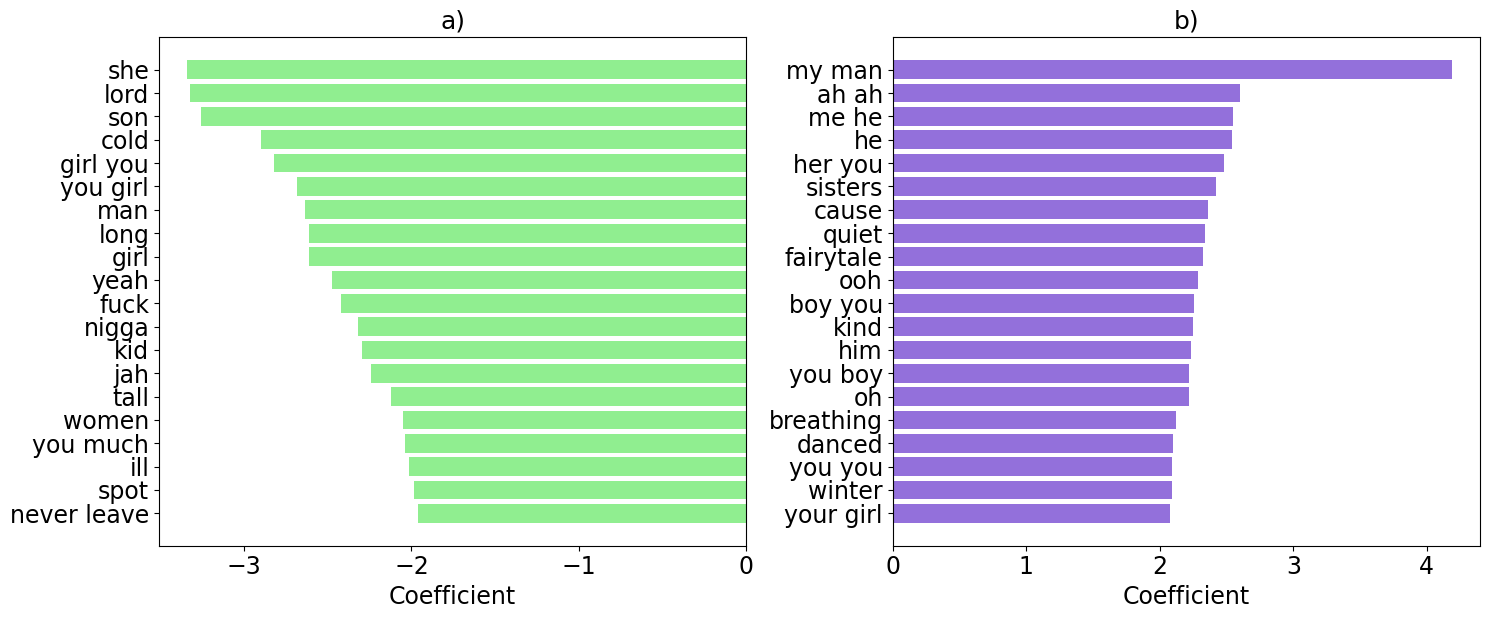

In [ ]:
# Figure 3: TF-IDF interpretability
import matplotlib.ticker as ticker

def plot_tfidf_top_coefficients(top_features: pd.DataFrame, output_path: Path, top_n: int = 20) -> None:
    title_size = 18
    label_size = 17
    tick_size = 17

    male_features = top_features[top_features["associated_class"] == "male"].head(top_n).copy()
    female_features = top_features[top_features["associated_class"] == "female"].head(top_n).copy()

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    fig.suptitle("", fontsize=16, fontweight="bold")

    male_plot = male_features.sort_values("coefficient", ascending=True)
    axes[0].barh(male_plot["feature"], male_plot["coefficient"], color="lightgreen")
    axes[0].set_title("a)", fontsize=title_size, fontweight="normal")
    axes[0].set_xlabel("Coefficient", fontsize=label_size)
    axes[0].tick_params(labelsize=tick_size)
    axes[0].invert_yaxis()

    axes[0].xaxis.set_major_locator(ticker.MultipleLocator(1))

    female_plot = female_features.sort_values("coefficient")
    axes[1].barh(female_plot["feature"], female_plot["coefficient"], color="mediumpurple")
    axes[1].set_title("b)", fontsize=title_size, fontweight="normal")
    axes[1].set_xlabel("Coefficient", fontsize=label_size)
    axes[1].tick_params(labelsize=tick_size)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    save_figure(output_path)
    plt.show()


plot_tfidf_top_coefficients(tfidf_top_features, FIGURES_DIR / "figure_4_tfidf_top_coefficients.png")

## 11. Model 2 — Fine-tuning BERT

This section fine-tunes `bert-base-uncased` for binary classification.

Important design choices:

- BERT receives `lyrics_clean_bert`, not the strongly cleaned TF-IDF text.
- Lyrics are truncated to the first 512 tokens.
- The class imbalance is handled using weighted cross-entropy.
- The best model is selected using validation macro-F1.
- Early stopping is used to avoid overfitting.


In [ ]:

# BERT imports and device setup

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:

# BERT dataset class


class LyricsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length: int):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.encodings = tokenizer(
            self.texts,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: value[idx]
            for key, value in self.encodings.items()
        }
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [ ]:

# Prepare BERT datasets and dataloaders

if RUN_BERT:
    tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)

    bert_train_dataset = LyricsDataset(
        train_df["lyrics_clean_bert"].tolist(),
        train_df["gender_label"].tolist(),
        tokenizer,
        MAX_LENGTH,
    )

    bert_val_dataset = LyricsDataset(
        val_df["lyrics_clean_bert"].tolist(),
        val_df["gender_label"].tolist(),
        tokenizer,
        MAX_LENGTH,
    )

    bert_test_dataset = LyricsDataset(
        test_df["lyrics_clean_bert"].tolist(),
        test_df["gender_label"].tolist(),
        tokenizer,
        MAX_LENGTH,
    )

    bert_train_loader = DataLoader(
        bert_train_dataset,
        batch_size=BERT_BATCH_SIZE,
        shuffle=True,
    )

    bert_val_loader = DataLoader(
        bert_val_dataset,
        batch_size=BERT_BATCH_SIZE,
        shuffle=False,
    )

    bert_test_loader = DataLoader(
        bert_test_dataset,
        batch_size=BERT_BATCH_SIZE,
        shuffle=False,
    )

    print("BERT train batches:", len(bert_train_loader))
    print("BERT validation batches:", len(bert_val_loader))
    print("BERT test batches:", len(bert_test_loader))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BERT train batches: 902
BERT validation batches: 187
BERT test batches: 191


In [ ]:

# BERT training and evaluation functions

if RUN_BERT:
    def evaluate_bert(model, dataloader, loss_fn=None):
        model.eval()

        total_loss = 0.0
        all_predictions = []
        all_labels = []

        with torch.no_grad():
            for batch in tqdm(dataloader, desc="Evaluating", leave=False):
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                )

                logits = outputs.logits

                if loss_fn is not None:
                    loss = loss_fn(logits, labels)
                    total_loss += loss.item()

                predictions = torch.argmax(logits, dim=1)

                all_predictions.extend(predictions.cpu().numpy().tolist())
                all_labels.extend(labels.cpu().numpy().tolist())

        metrics = compute_metrics(all_labels, all_predictions)
        avg_loss = total_loss / max(1, len(dataloader)) if loss_fn is not None else None

        return avg_loss, metrics, np.array(all_predictions), np.array(all_labels)


    def train_bert_model():
        model = AutoModelForSequenceClassification.from_pretrained(
            BERT_MODEL_NAME,
            num_labels=2,
        ).to(device)

        class_weights = compute_class_weight(
            class_weight="balanced",
            classes=np.array([0, 1]),
            y=train_df["gender_label"].values,
        )
        class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
        loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)

        optimizer = AdamW(
            model.parameters(),
            lr=BERT_LR,
            weight_decay=BERT_WEIGHT_DECAY,
        )

        total_training_steps = len(bert_train_loader) * BERT_EPOCHS
        warmup_steps = int(0.1 * total_training_steps)

        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=warmup_steps,
            num_training_steps=total_training_steps,
        )

        best_val_f1 = -1.0
        epochs_without_improvement = 0
        history = []
        best_model_dir = MODELS_DIR / "bert_best"

        for epoch in range(1, BERT_EPOCHS + 1):
            model.train()
            total_train_loss = 0.0

            for batch in tqdm(bert_train_loader, desc=f"Training epoch {epoch}"):
                optimizer.zero_grad()

                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                )

                logits = outputs.logits
                loss = loss_fn(logits, labels)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()

                total_train_loss += loss.item()

            avg_train_loss = total_train_loss / max(1, len(bert_train_loader))
            val_loss, val_metrics, _, _ = evaluate_bert(model, bert_val_loader, loss_fn=loss_fn)

            epoch_log = {
                "epoch": epoch,
                "train_loss": float(avg_train_loss),
                "val_loss": float(val_loss),
                "val_accuracy": float(val_metrics["accuracy"]),
                "val_f1_macro": float(val_metrics["f1_macro"]),
                "val_f1_weighted": float(val_metrics["f1_weighted"]),
            }
            history.append(epoch_log)

            print(epoch_log)

            if val_metrics["f1_macro"] > best_val_f1: # Save the model only if the F1 macro improves
                best_val_f1 = val_metrics["f1_macro"]
                epochs_without_improvement = 0

                best_model_dir.mkdir(parents=True, exist_ok=True)
                model.save_pretrained(best_model_dir)
                tokenizer.save_pretrained(best_model_dir)
                print(f"Saved new best BERT checkpoint to {best_model_dir}")
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= BERT_EARLY_STOPPING_PATIENCE:
                print("Early stopping triggered.")
                break

        history_df = pd.DataFrame(history)
        history_df.to_csv(RESULTS_DIR / "bert_training_history.csv", index=False)

        return history_df

In [ ]:

# Train BERT

if RUN_BERT:
    bert_start_time = time.time()
    bert_history_df = train_bert_model()
    bert_training_time = time.time() - bert_start_time

    save_json(
        {
            "bert_model_name": BERT_MODEL_NAME,
            "max_length": MAX_LENGTH,
            "batch_size": BERT_BATCH_SIZE,
            "epochs_configured": BERT_EPOCHS,
            "learning_rate": BERT_LR,
            "weight_decay": BERT_WEIGHT_DECAY,
            "training_time_minutes": round(bert_training_time / 60, 2),
        },
        LOGS_DIR / "bert_runtime_log.json",
    )

    display(bert_history_df)
else:
    bert_history_df = None

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training epoch 1:   0%|          | 0/902 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/187 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/187 [00:00<?, ?it/s]

{'epoch': 3, 'train_loss': 0.4571143759707786, 'val_loss': 0.737587973873883, 'val_accuracy': 0.6731283422459893, 'val_f1_macro': 0.6061307459591122, 'val_f1_weighted': 0.6850728083587226}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved new best BERT checkpoint to nlp_lyrics_gender_project/models/bert_best


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro,val_f1_weighted
0,1,0.672868,0.651149,0.568850,0.550152,0.594721
1,2,0.594023,0.661536,0.665441,0.605654,0.680272
2,3,0.457114,0.737588,0.673128,0.606131,0.685073


Saved figure: nlp_lyrics_gender_project/results/figures/figure_5_bert_learning_curves.png


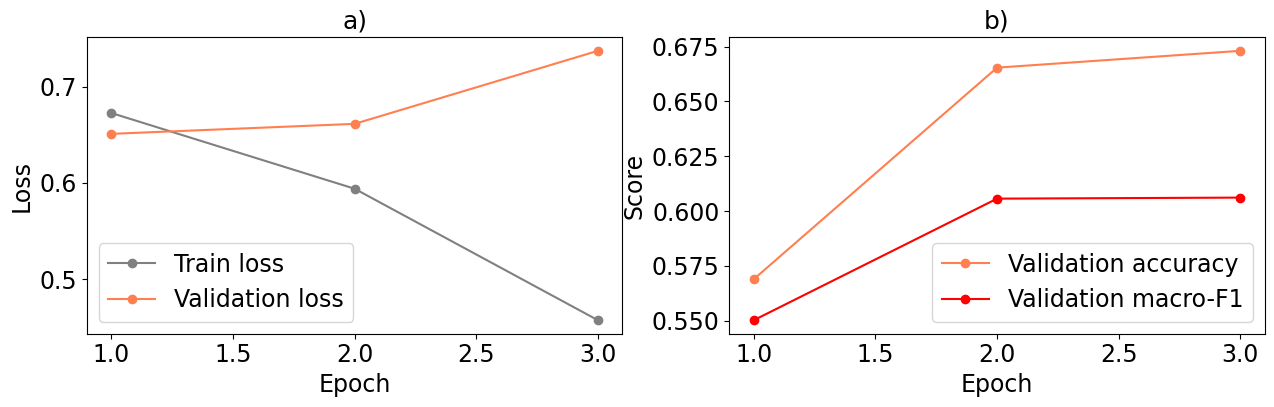

In [ ]:
# Figure 4: BERT learning curves

def plot_bert_learning_curves(history_df: pd.DataFrame, output_path: Path) -> None:
    title_size = 18
    label_size = 17
    tick_size = 17

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    fig.suptitle("", fontsize=16, fontweight="bold")

    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", color="gray", label="Train loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", color="coral", label="Validation loss")
    axes[0].set_title("a)", fontsize=title_size, fontweight="normal")
    axes[0].set_xlabel("Epoch", fontsize=label_size)
    axes[0].set_ylabel("Loss", fontsize=label_size)
    axes[0].legend(fontsize=tick_size)
    axes[0].tick_params(labelsize=tick_size, rotation=0)

    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", color="coral", label="Validation accuracy")
    axes[1].plot(history_df["epoch"], history_df["val_f1_macro"], marker="o", color="red", label="Validation macro-F1")
    axes[1].set_title("b)", fontsize=title_size, fontweight="normal")
    axes[1].set_xlabel("Epoch", fontsize=label_size)
    axes[1].set_ylabel("Score", fontsize=label_size)
    axes[1].legend(fontsize=tick_size)
    axes[1].tick_params(labelsize=tick_size, rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    save_figure(output_path)
    plt.show()


plot_bert_learning_curves(bert_history_df, FIGURES_DIR / "figure_5_bert_learning_curves.png")


In [ ]:

# Evaluate best BERT checkpoint on test set

if RUN_BERT:
    best_model_dir = MODELS_DIR / "bert_best"

    if not best_model_dir.exists():
        raise FileNotFoundError("No BERT checkpoint found. Run the BERT training cell first.")

    best_bert_model = AutoModelForSequenceClassification.from_pretrained(best_model_dir).to(device)

    bert_class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.array([0, 1]),
        y=train_df["gender_label"].values,
    )
    bert_class_weights = torch.tensor(bert_class_weights, dtype=torch.float).to(device)
    bert_loss_fn = torch.nn.CrossEntropyLoss(weight=bert_class_weights)

    bert_test_loss, bert_test_metrics, bert_test_predictions, bert_test_labels = evaluate_bert(
        best_bert_model,
        bert_test_loader,
        loss_fn=bert_loss_fn,
    )

    bert_confusion = confusion_matrix(bert_test_labels, bert_test_predictions, labels=[0, 1])
    bert_report = classification_report(
        bert_test_labels,
        bert_test_predictions,
        target_names=["male", "female"],
        zero_division=0,
        output_dict=True,
    )

    bert_results = {
        "model": "bert_sequence_classifier",
        "bert_model_name": BERT_MODEL_NAME,
        "max_length": MAX_LENGTH,
        "test_loss": float(bert_test_loss),
        "test_metrics": bert_test_metrics,
        "confusion_matrix": bert_confusion.tolist(),
        "classification_report": bert_report,
    }

    save_json(bert_results, RESULTS_DIR / "bert_results.json")

    bert_predictions_df = test_df[[
        "split_row_id",
        "artist_name",
        "artist_name_normalized",
        "lyrics_raw",
        "lyrics_clean_bert",
        "gender",
        "gender_label",
        "raw_word_count",
        "bert_word_count",
    ]].copy()

    bert_predictions_df["bert_pred_label"] = bert_test_predictions
    bert_predictions_df["bert_pred_gender"] = bert_predictions_df["bert_pred_label"].map({0: "male", 1: "female"})
    bert_predictions_df["bert_correct"] = bert_predictions_df["bert_pred_label"] == bert_predictions_df["gender_label"]

    bert_predictions_df.to_csv(RESULTS_DIR / "bert_test_predictions.csv", index=False)

    print("BERT test metrics:")
    print(json.dumps(bert_test_metrics, indent=2))
    print("Confusion matrix [[male, female], [male, female]]:")
    print(bert_confusion)
else:
    print("RUN_BERT is False. Skipping BERT test evaluation.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/191 [00:00<?, ?it/s]

BERT test metrics:
{
  "accuracy": 0.6753033781567727,
  "precision_macro": 0.6275710530639067,
  "recall_macro": 0.6319493449973712,
  "f1_macro": 0.6294065908809646,
  "precision_weighted": 0.6813586186046289,
  "recall_weighted": 0.6753033781567727,
  "f1_weighted": 0.6780409311722916,
  "precision_male": 0.77180877279448,
  "recall_male": 0.7482083134257047,
  "f1_male": 0.759825327510917,
  "support_male": 2093,
  "precision_female": 0.48333333333333334,
  "recall_female": 0.5156903765690377,
  "f1_female": 0.49898785425101216,
  "support_female": 956
}
Confusion matrix [[male, female], [male, female]]:
[[1566  527]
 [ 463  493]]


## 12. Comparative evaluation

This section loads the saved results for both models and creates a comparison table that can be directly inserted into the paper.

In [ ]:

# Load model results and build comparison table

available_result_files = {
    "TF-IDF + linear": RESULTS_DIR / "tfidf_results.json",
    "BERT": RESULTS_DIR / "bert_results.json",
}

comparison_rows = []

for model_name, result_path in available_result_files.items():
    if result_path.exists():
        result = load_json(result_path)
        metrics = result["test_metrics"]
        comparison_rows.append({
            "model": model_name,
            "accuracy": metrics["accuracy"],
            "precision_macro": metrics["precision_macro"],
            "recall_macro": metrics["recall_macro"],
            "f1_macro": metrics["f1_macro"],
            "f1_weighted": metrics["f1_weighted"],
            "precision_male": metrics["precision_male"],
            "recall_male": metrics["recall_male"],
            "precision_female": metrics["precision_female"],
            "recall_female": metrics["recall_female"],
        })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)


markdown_table = comparison_df.round(4).to_markdown(index=False)
latex_table = comparison_df.round(4).to_latex(index=False, float_format="%.4f")

with open(RESULTS_DIR / "model_comparison.md", "w", encoding="utf-8") as f:
    f.write(markdown_table)

with open(RESULTS_DIR / "model_comparison.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)

display(comparison_df.round(4))
print(markdown_table)


,model,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,precision_male,recall_male,precision_female,recall_female
0,TF-IDF + linear,0.6405,0.5951,0.6015,0.5969,0.6464,0.7545,0.7062,0.4358,0.4969
1,BERT,0.6753,0.6276,0.6319,0.6294,0.6780,0.7718,0.7482,0.4833,0.5157


| model           |   accuracy |   precision_macro |   recall_macro |   f1_macro |   f1_weighted |   precision_male |   recall_male |   precision_female |   recall_female |
|:----------------|-----------:|------------------:|---------------:|-----------:|--------------:|-----------------:|--------------:|-------------------:|----------------:|
| TF-IDF + linear |     0.6405 |            0.5951 |         0.6015 |     0.5969 |        0.6464 |           0.7545 |        0.7062 |             0.4358 |          0.4969 |
| BERT            |     0.6753 |            0.6276 |         0.6319 |     0.6294 |        0.678  |           0.7718 |        0.7482 |             0.4833 |          0.5157 |


Saved figure: nlp_lyrics_gender_project/results/figures/figure_6_confusion_matrices.png


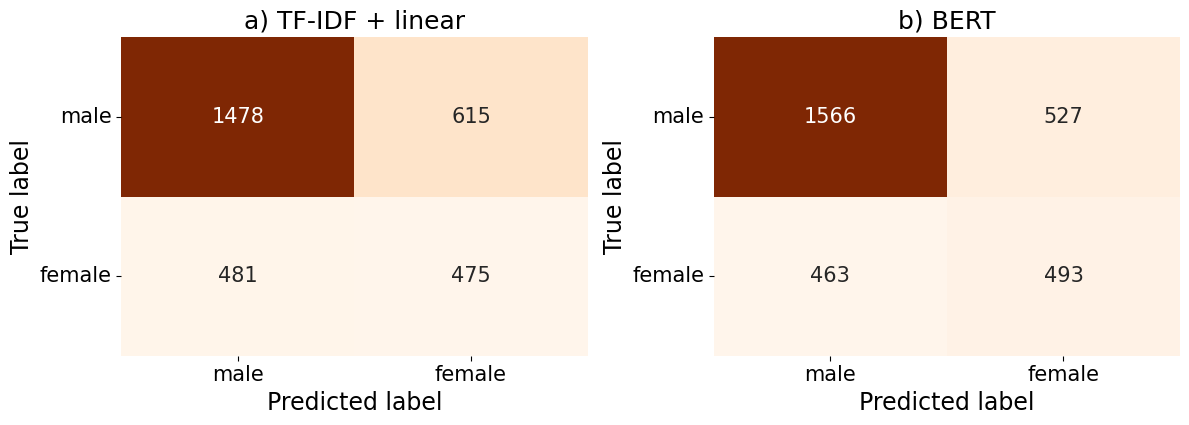

In [ ]:
# Figure 5: Comparative confusion matrices

def plot_comparative_confusion_matrices(output_path: Path) -> None:
    title_size = 18
    label_size = 17
    tick_size = 15

    result_files = []

    if (RESULTS_DIR / "tfidf_results.json").exists():
        result_files.append(("TF-IDF + linear", RESULTS_DIR / "tfidf_results.json"))

    if (RESULTS_DIR / "bert_results.json").exists():
        result_files.append(("BERT", RESULTS_DIR / "bert_results.json"))

    if not result_files:
        print("No confusion matrices available.")
        return

    fig, axes = plt.subplots(1, len(result_files), figsize=(6 * len(result_files), 5))
    if len(result_files) == 1:
        axes = [axes]

    fig.suptitle("", fontsize=16, fontweight="bold")

    for idx, (model_name, path) in enumerate(result_files):
        result = load_json(path)
        cm = np.array(result["confusion_matrix"])


        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cbar=False,
            cmap="Oranges",
            xticklabels=["male", "female"],
            yticklabels=["male", "female"],
            ax=axes[idx],
            annot_kws={"size": tick_size}
        )


        panel_letter = f"{chr(97 + idx)})"
        axes[idx].set_title(f"{panel_letter} {model_name}", fontsize=title_size, fontweight="normal")
        axes[idx].set_xlabel("Predicted label", fontsize=label_size)
        axes[idx].set_ylabel("True label", fontsize=label_size)
        axes[idx].tick_params(labelsize=tick_size, rotation=0)

    plt.tight_layout(rect=[0, 0, 1, 0.90])
    save_figure(output_path)
    plt.show()


plot_comparative_confusion_matrices(FIGURES_DIR / "figure_6_confusion_matrices.png")

Saved figure: nlp_lyrics_gender_project/results/figures/figure_7_metric_comparison.png


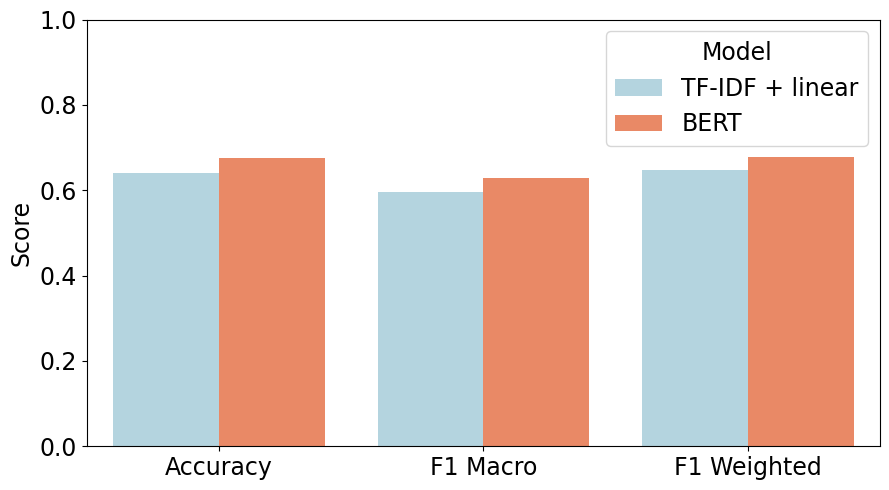

In [ ]:
# Figure 6: Metric comparison

def plot_metric_comparison(comparison_df: pd.DataFrame, output_path: Path) -> None:
    title_size = 18
    label_size = 17
    tick_size = 17

    if comparison_df.empty:
        print("No comparison data available.")
        return

    metrics_to_plot = ["accuracy", "f1_macro", "f1_weighted"]
    plot_df = comparison_df[["model"] + metrics_to_plot].melt(
        id_vars="model",
        var_name="metric",
        value_name="score",
    )

    metric_mapping = {
        "accuracy": "Accuracy",
        "f1_macro": "F1 Macro",
        "f1_weighted": "F1 Weighted"
    }
    plot_df["metric"] = plot_df["metric"].map(metric_mapping)

    color_palette = {
        "TF-IDF + linear": "lightblue",
        "BERT": "coral"
    }

    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=plot_df, x="metric", y="score", hue="model", palette=color_palette, ax=ax)
    ax.set_title("", fontsize=title_size, fontweight="normal")
    ax.set_ylim(0, 1)
    ax.set_xlabel("", fontsize=label_size)
    ax.set_ylabel("Score", fontsize=label_size)
    ax.legend(title="Model", fontsize=tick_size, title_fontsize=label_size)
    ax.tick_params(labelsize=tick_size, rotation=0)

    plt.tight_layout()
    save_figure(output_path)
    plt.show()


if "comparison_df" in globals():
    plot_metric_comparison(comparison_df, FIGURES_DIR / "figure_7_metric_comparison.png")

## 13. Statistical significance test

We use McNemar's test because both models have produced predictions on the same test set. This tests whether the difference in their error patterns is statistically significant.

In [ ]:

# McNemar significance test

def run_mcnemar_test(tfidf_path: Path, bert_path: Path):
    if not tfidf_path.exists() or not bert_path.exists():
        print("Both TF-IDF and BERT predictions are required for McNemar's test.")
        return None

    tfidf_pred = pd.read_csv(tfidf_path)
    bert_pred = pd.read_csv(bert_path)

    merged = tfidf_pred[["split_row_id", "gender_label", "tfidf_pred_label", "tfidf_correct"]].merge(
        bert_pred[["split_row_id", "bert_pred_label", "bert_correct"]],
        on="split_row_id",
        how="inner",
    )

    assert len(merged) == len(tfidf_pred) == len(bert_pred), "Prediction files are not aligned."

    a = int(((merged["tfidf_correct"] == True) & (merged["bert_correct"] == True)).sum())
    b = int(((merged["tfidf_correct"] == True) & (merged["bert_correct"] == False)).sum())
    c = int(((merged["tfidf_correct"] == False) & (merged["bert_correct"] == True)).sum())
    d = int(((merged["tfidf_correct"] == False) & (merged["bert_correct"] == False)).sum())

    contingency_table = [[a, b], [c, d]]

    try:
        from statsmodels.stats.contingency_tables import mcnemar
        result = mcnemar(contingency_table, exact=True)
        test_output = {
            "test": "McNemar exact test",
            "both_correct": a,
            "tfidf_correct_bert_wrong": b,
            "tfidf_wrong_bert_correct": c,
            "both_wrong": d,
            "statistic": float(result.statistic),
            "p_value": float(result.pvalue),
        }
    except Exception:
        from scipy.stats import chi2
        statistic = ((abs(b - c) - 1) ** 2) / (b + c) if (b + c) > 0 else 0.0
        p_value = float(chi2.sf(statistic, df=1))
        test_output = {
            "test": "McNemar chi-square approximation with continuity correction",
            "both_correct": a,
            "tfidf_correct_bert_wrong": b,
            "tfidf_wrong_bert_correct": c,
            "both_wrong": d,
            "statistic": float(statistic),
            "p_value": p_value,
        }

    save_json(test_output, RESULTS_DIR / "mcnemar_test.json")
    return test_output


mcnemar_output = run_mcnemar_test(
    RESULTS_DIR / "tfidf_test_predictions.csv",
    RESULTS_DIR / "bert_test_predictions.csv",
)

mcnemar_output

{'test': 'McNemar exact test',
 'both_correct': 1558,
 'tfidf_correct_bert_wrong': 395,
 'tfidf_wrong_bert_correct': 501,
 'both_wrong': 595,
 'statistic': 395.0,
 'p_value': 0.000445568308941295}

## 14. Error analysis

The dataset used in this stage only contains `artist_name`, `lyrics`, and `gender`. It does **not** contain music genre or year. Therefore, the main error analysis focuses on:

- songs misclassified by both models;
- artists with repeated misclassifications;
- lyric length and error patterns.

If future versions of the dataset include `music_genre`, `year`, or `song_name`, the code below can be extended to analyze errors by genre or period.

In [ ]:

# Error analysis for TF-IDF and BERT

def build_error_analysis():
    tfidf_path = RESULTS_DIR / "tfidf_test_predictions.csv"
    bert_path = RESULTS_DIR / "bert_test_predictions.csv"

    if not tfidf_path.exists():
        print("TF-IDF prediction file not found.")
        return None

    tfidf_pred = pd.read_csv(tfidf_path)

    if bert_path.exists():
        bert_pred = pd.read_csv(bert_path)
        errors = tfidf_pred.merge(
            bert_pred[["split_row_id", "bert_pred_label", "bert_pred_gender", "bert_correct"]],
            on="split_row_id",
            how="left",
        )
        errors["both_wrong"] = (~errors["tfidf_correct"]) & (~errors["bert_correct"])
        errors["models_disagree"] = errors["tfidf_pred_label"] != errors["bert_pred_label"]
    else:
        errors = tfidf_pred.copy()
        errors["both_wrong"] = ~errors["tfidf_correct"]
        errors["models_disagree"] = False

    both_wrong_df = errors[errors["both_wrong"]].copy()
    both_wrong_df.to_csv(RESULTS_DIR / "both_models_wrong_examples.csv", index=False)

    artist_error_summary = (
        errors.assign(any_error=~errors["tfidf_correct"])
        .groupby(["artist_name", "gender"])
        .agg(
            n_test_songs=("split_row_id", "count"),
            n_tfidf_errors=("tfidf_correct", lambda x: int((~x).sum())),
        )
        .reset_index()
    )

    if "bert_correct" in errors.columns:
        bert_artist_errors = (
            errors.groupby(["artist_name", "gender"])["bert_correct"]
            .apply(lambda x: int((~x).sum()))
            .reset_index(name="n_bert_errors")
        )
        artist_error_summary = artist_error_summary.merge(
            bert_artist_errors,
            on=["artist_name", "gender"],
            how="left",
        )

    artist_error_summary = artist_error_summary.sort_values(
        ["n_tfidf_errors", "n_test_songs"],
        ascending=False,
    )

    artist_error_summary.to_csv(RESULTS_DIR / "artist_error_summary.csv", index=False)

    print("Number of examples wrong for both available models:", len(both_wrong_df))
    display(both_wrong_df[["artist_name", "gender", "tfidf_pred_gender", "lyrics_raw"]].head(10))
    display(artist_error_summary.head(20))

    return errors, both_wrong_df, artist_error_summary


error_analysis_outputs = build_error_analysis()

Number of examples wrong for both available models: 595


,artist_name,gender,tfidf_pred_gender,lyrics_raw
14,Mila J,female,male,It's out of motion\n Killer potion\n Slippin' so so hard\n From sippin' so so hard\n You deserve a bad one\n The onl...
15,Billie Holiday,female,male,If practice makes perfect\n Let's try that old embrace\n In some romantic place\n Where we can take our time\n If pr...
22,Andrew Lloyd Webber,male,female,When all the world is a hopeless jumble\n And the raindrops tumble all around\n Heaven opens a magic lane\n ♪\n When...
33,Eilen Jewell,female,male,You picked up a broken bottle\n In case anyone gave us any trouble\n And we walked all the way back to Cortez\n You ...
47,Wooli,male,female,"I can't seem to catch my breath\n Feeling like light is fading fast\n I'm afraid imma crash, and never recover\n I t..."
51,Mariah Carey,female,male,God rest ye merry gentlemen\n Let nothin' you dismay\n Remember Christ our Savior\n Was born on Christmas day\n To s...
56,Billy Bragg,male,female,They were strolling in the gloaming\n Where the roses were in bloom\n A soldier and his sweetheart brave and true\n ...
64,Keith Whitley,male,female,Loving you was just a storybook of fair\n I've decided there ain't no real life anywhere\n Soon I'll be a faded pict...
65,Joss Stone,female,male,"Verse:\n Get your head out your dreams, they would say\n Ooh, shot me down time and time again\n Stubborn girl she r..."
67,Jacob Banks,male,female,"Eh, yeah, yeah, yeah\n Yeah, oh, yeah, yeah, yeah\n Yeah, oh, yeah, yeah, yeah, yeah\n The summer of '09\n Back wher..."


,artist_name,gender,n_test_songs,n_tfidf_errors,n_bert_errors
403,Emmylou Harris,female,31,18,21
824,Mariah Carey,female,23,13,9
356,Dionne Warwick,female,27,11,12
127,Beyoncé,female,21,10,11
1099,Sia,female,16,10,7
71,Andrew Lloyd Webber,male,19,9,10
1008,Reba McEntire,female,11,8,8
227,CeCe Winans,female,9,8,3
780,Loretta Lynn,female,9,8,7
1171,The Weeknd,male,24,7,5


## 16. Paper-ready methodological summary

You can reuse the following points in the paper:

- We frame the task as binary text classification from lyrics to singer gender.
- We remove multi-artist credits to reduce label ambiguity.
- We keep pronouns in the main experiment but explicitly acknowledge that they may provide a strong and potentially trivial signal.
- We split the data by artist to avoid leakage from artist-specific style.
- We use class weighting rather than undersampling to handle imbalance.
- We compare a transparent TF-IDF linear baseline with a contextual BERT classifier.
- We report accuracy, macro-F1, weighted-F1, per-class precision/recall, confusion matrices, and McNemar's test when both models are available.
- We interpret TF-IDF coefficients as model-specific discriminative features, not as causal evidence about gendered language.
- For BERT, we use first-512-token truncation and mention it as a limitation.